In [174]:
# Cell 1 - Imports & settings
import os
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import time
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.inspection import permutation_importance
from sklearn.base import clone

import joblib

# Optional libraries (may not be installed)
try:
    import lightgbm as lgb
    LGB_INSTALLED = True
except Exception:
    LGB_INSTALLED = False

try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline
    IMBLEARN_AVAILABLE = True
except Exception:
    IMBLEARN_AVAILABLE = False

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("cwd:", os.getcwd(), "LightGBM:", LGB_INSTALLED, "imblearn:", IMBLEARN_AVAILABLE)


cwd: c:\Users\Kivindu_PC\Downloads\ON-DEVICE AI SUMMARIZATION OF TEXT AND BEHAVIOR\ON-DEVICE AI SUMMARIZATION OF TEXT AND BEHAVIOR\backend\app LightGBM: True imblearn: True


In [175]:
# Cell 2 - find original CSV and create binary columns if needed
from pathlib import Path

def find_file_upwards(filename, start=Path.cwd()):
    p = Path(start).resolve()
    for parent in [p] + list(p.parents):
        candidate = parent / filename
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"{filename} not found starting at {p}")

orig_name = "final_cleaned_overstimulation_dataset_90to95_values_modified.csv"
try:
    orig_path = find_file_upwards(orig_name)
    print("Found original dataset at:", orig_path)
    df_orig = pd.read_csv(orig_path)
    print("Original shape:", df_orig.shape)
except FileNotFoundError:
    orig_path = None
    df_orig = None
    print(f"{orig_name} not found. Ensure the file exists in the notebook's folder tree.")

binary_name = "balanced_overstimulation_dataset_binary.csv"
if df_orig is not None:
    def to_binary(series, threshold=5):
        return series.apply(lambda x: 0 if pd.isna(x) or x <= threshold else 1)
    for col in ["Stress_Level", "Anxiety_Score", "Depression_Score"]:
        if col in df_orig.columns:
            df_orig[col + "_binary"] = to_binary(df_orig[col], threshold=5)
            print(f"Created {col + '_binary'} counts:\n", df_orig[col + "_binary"].value_counts(dropna=False))
        else:
            print(f"{col} not in dataset; skipping binary creation for it.")
    # Save binary CSV next to original in a 'backend' folder
    if orig_path is not None:
        repo_root = orig_path.parent
        backend_dir = repo_root / "backend"
        backend_dir.mkdir(parents=True, exist_ok=True)
        out_path = backend_dir / binary_name
        df_orig.to_csv(out_path, index=False)
        print("Saved binary dataset to:", out_path)
else:
    print("No original dataframe loaded; if you already have a binary CSV, place it in the repo tree.")


Found original dataset at: C:\Users\Kivindu_PC\Downloads\ON-DEVICE AI SUMMARIZATION OF TEXT AND BEHAVIOR\ON-DEVICE AI SUMMARIZATION OF TEXT AND BEHAVIOR\backend\app\final_cleaned_overstimulation_dataset_90to95_values_modified.csv
Original shape: (4408, 21)
Created Stress_Level_binary counts:
 Stress_Level_binary
1    2401
0    2007
Name: count, dtype: int64
Created Anxiety_Score_binary counts:
 Anxiety_Score_binary
1    2473
0    1935
Name: count, dtype: int64
Created Depression_Score_binary counts:
 Depression_Score_binary
0    2545
1    1863
Name: count, dtype: int64
Saved binary dataset to: C:\Users\Kivindu_PC\Downloads\ON-DEVICE AI SUMMARIZATION OF TEXT AND BEHAVIOR\ON-DEVICE AI SUMMARIZATION OF TEXT AND BEHAVIOR\backend\app\backend\balanced_overstimulation_dataset_binary.csv


In [176]:
# Cell 3 - load binary dataset (robust search) and inspect
binary_name = "balanced_overstimulation_dataset_binary.csv"
try:
    binary_path = find_file_upwards(binary_name)
    print("Using binary dataset at:", binary_path)
    df = pd.read_csv(binary_path)
except FileNotFoundError:
    raise FileNotFoundError(f"Binary dataset '{binary_name}' not found. Run Cell 2 or place it in a parent folder.")

print("Shape:", df.shape)
display(df.head())
print("\nColumns:", df.columns.tolist())
print("\nMissing values per column:")
display(df.isna().sum().sort_values(ascending=False))


Using binary dataset at: C:\Users\Kivindu_PC\Downloads\ON-DEVICE AI SUMMARIZATION OF TEXT AND BEHAVIOR\ON-DEVICE AI SUMMARIZATION OF TEXT AND BEHAVIOR\backend\app\balanced_overstimulation_dataset_binary.csv
Shape: (4408, 24)


,Age,Sleep_Hours,Screen_Time,Stress_Level,Noise_Exposure,Social_Interaction,Work_Hours,Exercise_Hours,Caffeine_Intake,Multitasking_Habit,...,Overthinking_Score,Irritability_Score,Headache_Frequency,Sleep_Quality,Tech_Usage_Hours,Overstimulated,Heart_Rate,Stress_Level_binary,Anxiety_Score_binary,Depression_Score_binary
0,25.0,8.669532,1.393073,6,1.195554,6.826367,9.415022,2.193698,3.0,1.0,...,4.0,3.595328,2.0,0.387995,6.278259,0,78.858760,1,0,0
1,28.0,7.827195,0.000757,9,1.309133,2.862529,-0.599859,0.488634,1.0,1.0,...,7.0,8.595328,4.0,2.553360,-0.986033,0,78.940950,1,0,0
2,28.0,9.508761,-0.879901,4,3.633790,6.414134,3.683534,1.385946,1.0,0.0,...,1.0,7.595328,4.0,3.734030,7.326594,0,74.901679,0,0,0
3,20.0,7.234202,0.927319,2,0.125390,3.905968,8.119267,0.583204,2.0,0.0,...,4.0,6.404672,5.0,3.338629,0.348054,0,80.290910,0,0,1
4,19.0,9.936243,9.788849,11,5.318015,6.279539,14.939917,2.268604,2.0,1.0,...,7.0,4.405812,2.0,0.014157,5.881821,1,91.345400,1,1,1



Columns: ['Age', 'Sleep_Hours', 'Screen_Time', 'Stress_Level', 'Noise_Exposure', 'Social_Interaction', 'Work_Hours', 'Exercise_Hours', 'Caffeine_Intake', 'Multitasking_Habit', 'Anxiety_Score', 'Depression_Score', 'Sensory_Sensitivity', 'Meditation_Habit', 'Overthinking_Score', 'Irritability_Score', 'Headache_Frequency', 'Sleep_Quality', 'Tech_Usage_Hours', 'Overstimulated', 'Heart_Rate', 'Stress_Level_binary', 'Anxiety_Score_binary', 'Depression_Score_binary']

Missing values per column:


Age                        0
Sleep_Hours                0
Screen_Time                0
Stress_Level               0
Noise_Exposure             0
Social_Interaction         0
Work_Hours                 0
Exercise_Hours             0
Caffeine_Intake            0
Multitasking_Habit         0
Anxiety_Score              0
Depression_Score           0
Sensory_Sensitivity        0
Meditation_Habit           0
Overthinking_Score         0
Irritability_Score         0
Headache_Frequency         0
Sleep_Quality              0
Tech_Usage_Hours           0
Overstimulated             0
Heart_Rate                 0
Stress_Level_binary        0
Anxiety_Score_binary       0
Depression_Score_binary    0
dtype: int64

In [177]:
# Cell 4 - define targets and base feature list (ensure no leakage)
possible_targets = {
    "Stress": ["Stress_Level_binary", "Stress_Level"],
    "Anxiety": ["Anxiety_Score_binary", "Anxiety_Score"],
    "Depression": ["Depression_Score_binary", "Depression_Score"]
}

targets = {}
for k, opts in possible_targets.items():
    for o in opts:
        if o in df.columns:
            targets[k] = o
            break
    if k not in targets:
        raise ValueError(f"Could not find target column for {k}. Searched: {opts}")

print("Targets chosen:", targets)

# Candidate features: all columns except the target columns and common ID/time fields
drop_candidates = set(targets.values()) | {"id","ID","participant_id","timestamp","time","index"}
feature_cols = [c for c in df.columns if c not in drop_candidates]
print("Number of candidate features:", len(feature_cols))
print("Example features:", feature_cols[:30])

# Print target distributions
for name, col in targets.items():
    print(f"{name} distribution ({col}):\n", df[col].value_counts())


Targets chosen: {'Stress': 'Stress_Level_binary', 'Anxiety': 'Anxiety_Score_binary', 'Depression': 'Depression_Score_binary'}
Number of candidate features: 21
Example features: ['Age', 'Sleep_Hours', 'Screen_Time', 'Stress_Level', 'Noise_Exposure', 'Social_Interaction', 'Work_Hours', 'Exercise_Hours', 'Caffeine_Intake', 'Multitasking_Habit', 'Anxiety_Score', 'Depression_Score', 'Sensory_Sensitivity', 'Meditation_Habit', 'Overthinking_Score', 'Irritability_Score', 'Headache_Frequency', 'Sleep_Quality', 'Tech_Usage_Hours', 'Overstimulated', 'Heart_Rate']
Stress distribution (Stress_Level_binary):
 Stress_Level_binary
1    2401
0    2007
Name: count, dtype: int64
Anxiety distribution (Anxiety_Score_binary):
 Anxiety_Score_binary
1    2473
0    1935
Name: count, dtype: int64
Depression distribution (Depression_Score_binary):
 Depression_Score_binary
0    2545
1    1863
Name: count, dtype: int64


In [178]:
# Cell 5 - safe feature engineering: num_missing, a few ratio features
df_fe = df.copy()
df_fe["num_missing"] = df_fe[feature_cols].isna().sum(axis=1)

# Create a few safe ratio features using the first few numeric columns (conservative)
numeric_candidates = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df_fe[c])]
sel = numeric_candidates[:8]  # conservative set
eng_cols = []
for i in range(len(sel)):
    for j in range(i+1, min(i+4, len(sel))):
        a, b = sel[i], sel[j]
        colname = f"{a}_div_{b}"
        df_fe[colname] = df_fe[a] / (df_fe[b] + 1e-6)
        eng_cols.append(colname)

# Update feature list (do not include raw target columns)
feature_cols = [c for c in df_fe.columns if c not in set(targets.values()) and c not in {"id","ID","participant_id","timestamp","time","index"}]
print("Added engineered columns:", eng_cols)
print("Total features for modeling:", len(feature_cols))


Added engineered columns: ['Age_div_Sleep_Hours', 'Age_div_Screen_Time', 'Age_div_Stress_Level', 'Sleep_Hours_div_Screen_Time', 'Sleep_Hours_div_Stress_Level', 'Sleep_Hours_div_Noise_Exposure', 'Screen_Time_div_Stress_Level', 'Screen_Time_div_Noise_Exposure', 'Screen_Time_div_Social_Interaction', 'Stress_Level_div_Noise_Exposure', 'Stress_Level_div_Social_Interaction', 'Stress_Level_div_Work_Hours', 'Noise_Exposure_div_Social_Interaction', 'Noise_Exposure_div_Work_Hours', 'Noise_Exposure_div_Exercise_Hours', 'Social_Interaction_div_Work_Hours', 'Social_Interaction_div_Exercise_Hours', 'Work_Hours_div_Exercise_Hours']
Total features for modeling: 40


In [179]:
df_fe

,Age,Sleep_Hours,Screen_Time,Stress_Level,Noise_Exposure,Social_Interaction,Work_Hours,Exercise_Hours,Caffeine_Intake,Multitasking_Habit,...,Screen_Time_div_Social_Interaction,Stress_Level_div_Noise_Exposure,Stress_Level_div_Social_Interaction,Stress_Level_div_Work_Hours,Noise_Exposure_div_Social_Interaction,Noise_Exposure_div_Work_Hours,Noise_Exposure_div_Exercise_Hours,Social_Interaction_div_Work_Hours,Social_Interaction_div_Exercise_Hours,Work_Hours_div_Exercise_Hours
0,25.000000,8.669532,1.393073,6,1.195554,6.826367,9.415022,2.193698,3.000000,1.000000,...,0.204072,5.018588,0.878945,0.637279,0.175138,0.126984,0.544995,0.725051,3.111807,4.291848
1,28.000000,7.827195,0.000757,9,1.309133,2.862529,-0.599859,0.488634,1.000000,1.000000,...,0.000265,6.874772,3.144071,-15.003554,0.457334,-2.182406,2.679163,-4.772013,5.858215,-1.227621
2,28.000000,9.508761,-0.879901,4,3.633790,6.414134,3.683534,1.385946,1.000000,0.000000,...,-0.137182,1.100779,0.623623,1.085913,0.566528,0.986495,2.621883,1.741298,4.627981,2.657775
3,20.000000,7.234202,0.927319,2,0.125390,3.905968,8.119267,0.583204,2.000000,0.000000,...,0.237411,15.950057,0.512037,0.246328,0.032102,0.015444,0.215002,0.481074,6.697414,13.921798
4,19.000000,9.936243,9.788849,11,5.318015,6.279539,14.939917,2.268604,2.000000,1.000000,...,1.558848,2.068441,1.751721,0.736282,0.846880,0.355960,2.344178,0.420320,2.768018,6.585509
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4403,22.668661,5.036558,10.746105,6,3.999716,7.308034,9.109409,1.331456,1.796728,0.490910,...,1.470451,1.500106,0.821014,0.658660,0.547304,0.439075,3.004014,0.802251,5.488749,6.841684
4404,22.840047,4.482446,10.029054,11,3.479649,10.625569,12.621383,0.618777,1.747220,0.684846,...,0.943860,3.161237,1.035239,0.871537,0.327479,0.275695,5.623418,0.841870,17.171851,20.397261
4405,23.600486,4.256880,10.697813,9,3.350207,8.171604,13.295192,0.723003,1.729830,0.603685,...,1.309145,2.686400,1.101375,0.676936,0.409982,0.251986,4.633731,0.614628,11.302291,18.388815
4406,23.523018,7.650804,2.205158,2,0.056544,-1.985873,4.540108,2.568397,1.476283,0.507736,...,-1.110423,35.369947,-1.007114,0.440518,-0.028473,0.012454,0.022015,-0.437406,-0.773195,1.767681


In [180]:
# --- PURGE: backup df_fe and remove target columns from df_fe, feature_cols, and metadata ---
targets_to_remove = [
    "Stress_Level","Stress_Level_binary",
    "Anxiety_Score","Anxiety_Score_binary",
    "Depression_Score","Depression_Score_binary",
    "Overstimulated"
]

# 1) backup
if "df_fe" not in globals():
    raise RuntimeError("df_fe not found — run data-loading cells first.")
df_fe_backup = df_fe.copy()
print("Backed up df_fe -> df_fe_backup (in-memory). Shape:", df_fe.shape)

# 2) drop from df_fe
dropped = [t for t in targets_to_remove if t in df_fe.columns]
if dropped:
    df_fe.drop(columns=dropped, inplace=True)
    print("Dropped from df_fe:", dropped)
else:
    print("No target columns present in df_fe to drop.")

# 3) clean global feature_cols (if present)
if "feature_cols" in globals() and isinstance(feature_cols, (list,tuple)):
    before = len(feature_cols)
    feature_cols = [c for c in feature_cols if c not in targets_to_remove]
    globals()["feature_cols"] = feature_cols
    print(f"Cleaned feature_cols: {before} -> {len(feature_cols)}")

# 4) clean search_results/simple_results 'feats' lists if present
def _clean_feats(d, name):
    if not isinstance(d, dict):
        return
    for target, info in d.items():
        if isinstance(info, dict) and info.get("feats"):
            orig = info["feats"]
            cleaned = [c for c in orig if c not in targets_to_remove]
            d[target]["feats"] = cleaned
            if len(cleaned) != len(orig):
                print(f"Removed targets from {name}['{target}'].feats ({len(orig)} -> {len(cleaned)})")
if "search_results" in globals():
    _clean_feats(search_results, "search_results")
if "simple_results" in globals():
    _clean_feats(simple_results, "simple_results")

print("Purge completed. Note: models already trained and saved earlier may still internally rely on leaked columns and must be retrained.")


Backed up df_fe -> df_fe_backup (in-memory). Shape: (4408, 43)
Dropped from df_fe: ['Stress_Level', 'Stress_Level_binary', 'Anxiety_Score', 'Anxiety_Score_binary', 'Depression_Score', 'Depression_Score_binary', 'Overstimulated']
Cleaned feature_cols: 40 -> 36
Purge completed. Note: models already trained and saved earlier may still internally rely on leaked columns and must be retrained.


In [181]:
# Cell 6 - preprocessor factory (encoder compatibility for sklearn versions)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

def make_onehot_encoder():
    # compatible OneHotEncoder construction for different sklearn versions
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        # old versions used 'sparse' parameter
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

def build_preprocessor(features, df_source):
    num_feats = [c for c in features if pd.api.types.is_numeric_dtype(df_source[c])]
    cat_feats = [c for c in features if c not in num_feats]
    print("Preprocessor -> numeric:", len(num_feats), "categorical:", len(cat_feats))
    num_pipe = Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())])
    cat_pipe = Pipeline([("impute", SimpleImputer(strategy="most_frequent")), ("onehot", make_onehot_encoder())]) if len(cat_feats)>0 else None
    transformers = [("num", num_pipe, num_feats)]
    if cat_pipe is not None:
        transformers.append(("cat", cat_pipe, cat_feats))
    preproc = ColumnTransformer(transformers, remainder="drop")
    return preproc


In [182]:
# Cell 7 - robust train/evaluate function (supports SMOTE fallback and tuning)
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV

def train_evaluate_pipeline(df_X, y, features, model_name="hgb", use_smote=False, tune=False, n_iter=20):
    X = df_X[features].copy()
    counts = y.value_counts()
    print("Target class counts:", counts.to_dict())
    if y.nunique() < 2:
        raise ValueError("Target has only one class.")

    # choose estimator & param grid
    if model_name == "hgb":
        estimator = HistGradientBoostingClassifier(random_state=RANDOM_STATE)
        param_dist = {"clf__max_iter":[100,200,400], "clf__max_leaf_nodes":[15,31,63,None], "clf__learning_rate":[0.01,0.05,0.1]}
    elif model_name == "rf":
        estimator = RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1)
        param_dist = {"clf__n_estimators":[100,200,400], "clf__max_depth":[None,10,20], "clf__min_samples_leaf":[1,2,4]}
    elif model_name == "lgb" and LGB_INSTALLED:
        estimator = lgb.LGBMClassifier(random_state=RANDOM_STATE, n_jobs=-1)
        param_dist = {"clf__n_estimators":[100,200,400], "clf__learning_rate":[0.01,0.05,0.1], "clf__num_leaves":[31,63]}
    else:
        estimator = LogisticRegression(max_iter=500, random_state=RANDOM_STATE)
        param_dist = {"clf__C":[0.01,0.1,1,10]}

    preproc = build_preprocessor(features, df_X)

    if use_smote and IMBLEARN_AVAILABLE:
        pipe = ImbPipeline([("preproc", preproc), ("smote", SMOTE(random_state=RANDOM_STATE)), ("clf", estimator)])
    else:
        pipe = Pipeline([("preproc", preproc), ("clf", estimator)])

    # try stratified split; fallback to non-stratified if class counts too small
    try:
        if counts.min() >= 2:
            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
        else:
            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, shuffle=True)
    except Exception as e:
        print("Split error, falling back to non-stratified:", e)
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, shuffle=True)

    # tune if requested
    if tune:
        try:
            cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)
            rnd = RandomizedSearchCV(pipe, param_dist, n_iter=n_iter, scoring="accuracy", cv=cv, random_state=RANDOM_STATE, n_jobs=-1, verbose=0)
            rnd.fit(X_train, y_train)
            best_pipe = rnd.best_estimator_
            print("Tuning done. best params:", getattr(rnd, "best_params_", None))
        except Exception as e:
            print("Tuning failed, falling back to train without tuning:", e)
            best_pipe = pipe.fit(X_train, y_train)
    else:
        best_pipe = pipe.fit(X_train, y_train)

    # evaluate on holdout
    y_pred = best_pipe.predict(X_test)
    try:
        y_proba = best_pipe.predict_proba(X_test)[:,1]
    except Exception:
        y_proba = None

    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan
    }
    print("Eval metrics:", metrics)
    print(classification_report(y_test, y_pred, zero_division=0))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d"); plt.title("Confusion matrix"); plt.show()

    return best_pipe, metrics, (X_test, y_test)


In [183]:
# Cell 8 (REPLACEMENT) - permutation importance to pick top-K candidate features per target (robust, no-leak)
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

topk_candidates = {}

# required: df_fe (cleaned features) and df_fe_backup (original with targets) should exist
if "df_fe" not in globals():
    raise RuntimeError("df_fe not found. Run data-loading / feature-engineering first.")
if "df_fe_backup" not in globals():
    print("Warning: df_fe_backup not found. If you previously purged targets you'll need df_fe_backup to supply y values.")

for name in ["Stress","Anxiety","Depression"]:
    print("\n" + "="*40, name)
    # Determine target column name from 'targets' map
    tcol = targets.get(name) if "targets" in globals() else None
    if tcol is None:
        print(f"  No target mapping for {name} in 'targets' dict. Skipping.")
        continue

    # Build conservative feature list: remove raw continuous scores and any columns that match target names
    remove_names = []
    for raw in ["Stress_Level","Anxiety_Score","Depression_Score"]:
        if raw in feature_cols:
            remove_names.append(raw)
    # also remove any direct target column names if present in feature_cols (binary / score)
    for t in [tcol, tcol.replace("_binary","")]:
        if t in feature_cols:
            remove_names.append(t)

    feat_list = [c for c in feature_cols if c not in set(remove_names)]
    print("Using features count:", len(feat_list))

    # Build X from cleaned df_fe (no label columns)
    X = df_fe[feat_list].copy()

    # Build y: prefer df_fe if it still contains target, else use df_fe_backup (original)
    if tcol in df_fe.columns:
        y = df_fe[tcol].astype(int)
        print("  Using y from df_fe (target present).")
    elif "df_fe_backup" in globals() and tcol in df_fe_backup.columns:
        # Use backup's target values, but ensure index alignment by reindexing to df_fe's index if necessary
        # We will align X (which has df_fe's index) with y by reindexing y to X.index
        y_full = df_fe_backup[tcol].astype(int)
        # If shapes match and indices align, use directly; otherwise reindex on shared index
        if list(y_full.index) == list(df_fe.index):
            y = y_full
            print("  Using y from df_fe_backup (indices matched).")
        else:
            # reindex using positional sample ordering: assume rows correspond; else force align by reset_index
            # safest is to reindex by position: convert to numpy and pick rows corresponding to X's index positions
            try:
                # if df_fe and df_fe_backup share same number of rows, align by position
                if len(df_fe_backup) == len(df_fe):
                    y = pd.Series(y_full.values, index=df_fe.index)
                    print("  Using y from df_fe_backup (aligned by position).")
                else:
                    # fallback: limit to indices that exist in both
                    common_idx = X.index.intersection(y_full.index)
                    if len(common_idx) == 0:
                        raise RuntimeError("No overlapping indices between df_fe and df_fe_backup; cannot align y.")
                    y = y_full.reindex(common_idx)
                    X = X.loc[common_idx]
                    print(f"  Using y from df_fe_backup reindexed to common indices ({len(common_idx)} rows).")
            except Exception as e:
                raise RuntimeError(f"Failed to align y from df_fe_backup to X: {e}")
    else:
        raise RuntimeError(f"Target column {tcol} not found in df_fe or df_fe_backup. Cannot compute y for {name}.")

    # quick target counts check
    vc = y.value_counts()
    print("Target counts:", vc.to_dict())
    if y.nunique() < 2:
        print(f"Skipping {name}: single-class target.")
        continue

    # split safely (stratify if possible)
    if vc.min() >= 2:
        X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
    else:
        X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, shuffle=True)

    # preprocess using the same preproc builder (fit only on training split)
    preproc = build_preprocessor(feat_list, df_fe)
    X_train_t = preproc.fit_transform(X_train)
    X_val_t = preproc.transform(X_val)

    rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, class_weight="balanced", n_jobs=-1)
    rf.fit(X_train_t, y_train)

    perm = permutation_importance(rf, X_val_t, y_val, n_repeats=20, random_state=RANDOM_STATE, n_jobs=-1)
    imp = pd.Series(perm.importances_mean, index=feat_list).sort_values(ascending=False)
    display(imp.head(25))

    for K in (8,12,16,20):
        topk_candidates.setdefault(name, {})[K] = imp.head(K).index.tolist()
    print("Top-12 preview:", topk_candidates[name][12])



======================================== Stress
Using features count: 36
  Using y from df_fe_backup (indices matched).
Target counts: {1: 2401, 0: 2007}
Preprocessor -> numeric: 36 categorical: 0


Age_div_Stress_Level                   2.516440e-01
Stress_Level_div_Work_Hours            3.424036e-02
Age                                    2.721088e-02
Sleep_Hours_div_Stress_Level           9.013605e-03
Heart_Rate                             8.163265e-03
Work_Hours                             6.462585e-03
Screen_Time_div_Stress_Level           6.405896e-03
Screen_Time                            2.380952e-03
Social_Interaction                     1.870748e-03
Noise_Exposure                         1.814059e-03
Stress_Level_div_Noise_Exposure        1.700680e-03
Stress_Level_div_Social_Interaction    1.360544e-03
Headache_Frequency                     1.077098e-03
Tech_Usage_Hours                       6.235828e-04
Sleep_Hours                            3.401361e-04
Screen_Time_div_Noise_Exposure         3.401361e-04
Irritability_Score                     1.700680e-04
Sensory_Sensitivity                    1.700680e-04
Noise_Exposure_div_Exercise_Hours      5.668934e-05
Work_Hours_d

Top-12 preview: ['Age_div_Stress_Level', 'Stress_Level_div_Work_Hours', 'Age', 'Sleep_Hours_div_Stress_Level', 'Heart_Rate', 'Work_Hours', 'Screen_Time_div_Stress_Level', 'Screen_Time', 'Social_Interaction', 'Noise_Exposure', 'Stress_Level_div_Noise_Exposure', 'Stress_Level_div_Social_Interaction']

======================================== Anxiety
Using features count: 36
  Using y from df_fe_backup (indices matched).
Target counts: {1: 2473, 0: 1935}
Preprocessor -> numeric: 36 categorical: 0


Tech_Usage_Hours                       0.019161
Sensory_Sensitivity                    0.015760
num_missing                            0.000000
Age_div_Stress_Level                  -0.000397
Multitasking_Habit                    -0.001134
Sleep_Hours_div_Screen_Time           -0.001247
Social_Interaction                    -0.001304
Irritability_Score                    -0.001701
Noise_Exposure_div_Exercise_Hours     -0.002381
Social_Interaction_div_Work_Hours     -0.002778
Sleep_Hours                           -0.002948
Age                                   -0.003005
Screen_Time_div_Social_Interaction    -0.003288
Sleep_Quality                         -0.003401
Stress_Level_div_Social_Interaction   -0.003571
Screen_Time                           -0.003571
Heart_Rate                            -0.003571
Sleep_Hours_div_Stress_Level          -0.003571
Caffeine_Intake                       -0.003571
Work_Hours                            -0.003798
Exercise_Hours                        -0

Top-12 preview: ['Tech_Usage_Hours', 'Sensory_Sensitivity', 'num_missing', 'Age_div_Stress_Level', 'Multitasking_Habit', 'Sleep_Hours_div_Screen_Time', 'Social_Interaction', 'Irritability_Score', 'Noise_Exposure_div_Exercise_Hours', 'Social_Interaction_div_Work_Hours', 'Sleep_Hours', 'Age']

======================================== Depression
Using features count: 36
  Using y from df_fe_backup (indices matched).
Target counts: {0: 2545, 1: 1863}
Preprocessor -> numeric: 36 categorical: 0


Irritability_Score                       0.104308
Sleep_Quality                            0.025624
Sleep_Hours                              0.007823
Noise_Exposure                           0.004649
Sensory_Sensitivity                      0.003628
Social_Interaction_div_Exercise_Hours    0.001871
Stress_Level_div_Work_Hours              0.000624
Tech_Usage_Hours                         0.000624
num_missing                              0.000000
Overthinking_Score                      -0.000113
Screen_Time                             -0.000170
Heart_Rate                              -0.000510
Multitasking_Habit                      -0.000510
Stress_Level_div_Social_Interaction     -0.000567
Work_Hours                              -0.000794
Sleep_Hours_div_Stress_Level            -0.000964
Caffeine_Intake                         -0.001474
Meditation_Habit                        -0.001701
Stress_Level_div_Noise_Exposure         -0.001757
Screen_Time_div_Noise_Exposure          -0.002098


Top-12 preview: ['Irritability_Score', 'Sleep_Quality', 'Sleep_Hours', 'Noise_Exposure', 'Sensory_Sensitivity', 'Social_Interaction_div_Exercise_Hours', 'Stress_Level_div_Work_Hours', 'Tech_Usage_Hours', 'num_missing', 'Overthinking_Score', 'Screen_Time', 'Heart_Rate']


In [184]:
# --- ASSERT: stop if any label columns are still present (safety gate before training) ---
targets_present = [t for t in [
    "Stress_Level","Stress_Level_binary",
    "Anxiety_Score","Anxiety_Score_binary",
    "Depression_Score","Depression_Score_binary","Overstimulated"
] if t in df_fe.columns]

if targets_present:
    raise RuntimeError("Detected target columns still present in df_fe: {}. Remove them before training.".format(targets_present))
else:
    print("No target columns in df_fe — safe to train.")


No target columns in df_fe — safe to train.


Safe feature pool size: 30 removed at start: ['Age_div_Stress_Level', 'Sleep_Hours_div_Stress_Level', 'Screen_Time_div_Stress_Level', 'Stress_Level_div_Noise_Exposure', 'Stress_Level_div_Social_Interaction', 'Stress_Level_div_Work_Hours']

Training simple NO-LEAK model for: Stress
  Using y from df_fe_backup (indices matched).
  Using 6 features (example first 12): ['Age', 'Heart_Rate', 'Work_Hours', 'Screen_Time', 'Social_Interaction', 'Noise_Exposure']
Preprocessor -> numeric: 6 categorical: 0
  Using SMOTE in pipeline

Stress metrics (no-leak):
  Accuracy:  0.8311
  Precision: 0.8441
  Recall:    0.8458
  F1:        0.8450
  ROC AUC:   0.9181

Classification report:
              precision    recall  f1-score   support

           0       0.82      0.81      0.81       402
           1       0.84      0.85      0.84       480

    accuracy                           0.83       882
   macro avg       0.83      0.83      0.83       882
weighted avg       0.83      0.83      0.83       

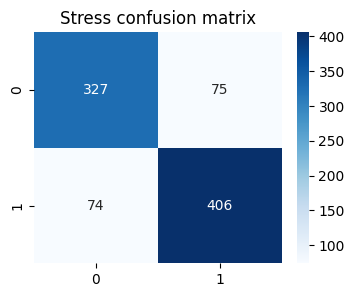

  Saved pipeline to: models_simple_no_leak\stress_simple_noleak_pipeline.joblib

Training simple NO-LEAK model for: Anxiety
  Using y from df_fe_backup (indices matched).
  Using 11 features (example first 12): ['Tech_Usage_Hours', 'Sensory_Sensitivity', 'num_missing', 'Multitasking_Habit', 'Sleep_Hours_div_Screen_Time', 'Social_Interaction', 'Irritability_Score', 'Noise_Exposure_div_Exercise_Hours', 'Social_Interaction_div_Work_Hours', 'Sleep_Hours', 'Age']
Preprocessor -> numeric: 11 categorical: 0
  Using SMOTE in pipeline

Anxiety metrics (no-leak):
  Accuracy:  0.6995
  Precision: 0.7337
  Recall:    0.7293
  F1:        0.7315
  ROC AUC:   0.7607

Classification report:
              precision    recall  f1-score   support

           0       0.66      0.66      0.66       387
           1       0.73      0.73      0.73       495

    accuracy                           0.70       882
   macro avg       0.70      0.70      0.70       882
weighted avg       0.70      0.70      0.70 

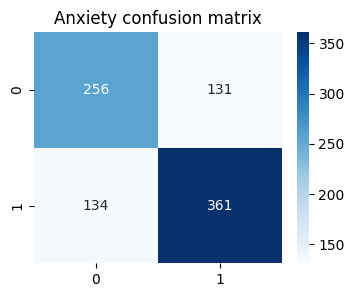

  Saved pipeline to: models_simple_no_leak\anxiety_simple_noleak_pipeline.joblib

Training simple NO-LEAK model for: Depression
  Using y from df_fe_backup (indices matched).
  Using 11 features (example first 12): ['Irritability_Score', 'Sleep_Quality', 'Sleep_Hours', 'Noise_Exposure', 'Sensory_Sensitivity', 'Social_Interaction_div_Exercise_Hours', 'Tech_Usage_Hours', 'num_missing', 'Overthinking_Score', 'Screen_Time', 'Heart_Rate']
Preprocessor -> numeric: 11 categorical: 0
  Using SMOTE in pipeline

Depression metrics (no-leak):
  Accuracy:  0.7800
  Precision: 0.7550
  Recall:    0.7105
  F1:        0.7320
  ROC AUC:   0.8614

Classification report:
              precision    recall  f1-score   support

           0       0.80      0.83      0.81       509
           1       0.75      0.71      0.73       373

    accuracy                           0.78       882
   macro avg       0.78      0.77      0.77       882
weighted avg       0.78      0.78      0.78       882



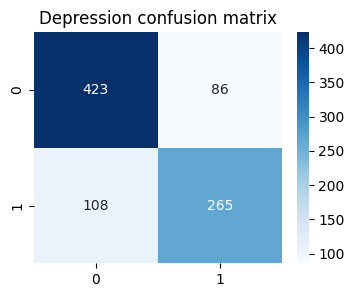

  Saved pipeline to: models_simple_no_leak\depression_simple_noleak_pipeline.joblib

Summary no-leak simple models:


,accuracy,precision,recall,f1,roc_auc
Stress,0.831066,0.844075,0.845833,0.844953,0.918097
Anxiety,0.699546,0.733740,0.729293,0.731510,0.760671
Depression,0.780045,0.754986,0.710456,0.732044,0.861351


In [185]:
# Cell 9 (REPLACEMENT) - simple no-leak models (robust to purged df_fe)
import joblib
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

models_simple_dir = Path("models_simple_no_leak")
models_simple_dir.mkdir(parents=True, exist_ok=True)

DEFAULT_K = 12
simple_results = {}

# define leakage substrings to ban (raw scores and any derived features containing them)
leak_substrings = ["Stress_Level", "Anxiety_Score", "Depression_Score"]

def remove_leak_features(feature_list):
    """Return list with any column removed that contains any leak substring."""
    clean = [f for f in feature_list if not any(sub in f for sub in leak_substrings)]
    removed = [f for f in feature_list if f not in clean]
    return clean, removed

# Ensure feature_cols exists
if "feature_cols" not in globals():
    raise RuntimeError("feature_cols not found. Ensure feature engineering cell ran and feature_cols is defined.")

# Safe feature pool: remove any exact target column names if present
safe_features_full = [c for c in feature_cols if c not in (list(targets.values()) if "targets" in globals() else [])]
safe_features_full, removed_initial = remove_leak_features(safe_features_full)
print("Safe feature pool size:", len(safe_features_full), "removed at start:", removed_initial)

# Ensure df_fe exists (cleaned features)
if "df_fe" not in globals():
    raise RuntimeError("df_fe not found. Run feature-engineering / purge cells first.")
# For targets we will prefer df_fe if available, otherwise use df_fe_backup
if "df_fe_backup" not in globals():
    print("Warning: df_fe_backup not found. If you purged targets earlier, create df_fe_backup = original_df.copy() before running.")

for name in ["Stress", "Anxiety", "Depression"]:
    print("\n" + "="*60)
    print("Training simple NO-LEAK model for:", name)
    if "targets" not in globals() or name not in targets:
        print(f"  No mapping for {name} in 'targets' dict — skipping.")
        simple_results[name] = {"error": "no_target_mapping"}
        continue
    target_col = targets[name]

    # Build y: prefer df_fe, else try df_fe_backup
    if target_col in df_fe.columns:
        y = df_fe[target_col].astype(int)
        print("  Using y from df_fe (target present). WARNING: this is unusual if you purged targets.")
    else:
        if "df_fe_backup" not in globals():
            raise RuntimeError(f"Target {target_col} not in df_fe and df_fe_backup not found. Cannot train {name}.")
        y_full = df_fe_backup[target_col].astype(int)
        # Align y to df_fe by index if possible
        if list(y_full.index) == list(df_fe.index):
            y = y_full
            print("  Using y from df_fe_backup (indices matched).")
        else:
            # If lengths equal, align by position
            if len(y_full) == len(df_fe):
                y = pd.Series(y_full.values, index=df_fe.index)
                print("  Using y from df_fe_backup (aligned by position).")
            else:
                # fallback: intersect indices
                common_idx = df_fe.index.intersection(y_full.index)
                if len(common_idx) == 0:
                    raise RuntimeError(f"No overlapping indices between df_fe and df_fe_backup for target {target_col}.")
                y = y_full.reindex(common_idx)
                print(f"  Using y from df_fe_backup reindexed to common indices ({len(common_idx)} rows).")

    # Skip if single-class
    if y.nunique() < 2:
        print(f"  Skipping {name}: only one class present: {y.value_counts().to_dict()}")
        simple_results[name] = {"error": "single_class", "counts": y.value_counts().to_dict()}
        continue

    # Build candidate features: prefer topk_candidates if available (but filter leak substrings)
    feats = None
    if "topk_candidates" in globals() and name in topk_candidates and DEFAULT_K in topk_candidates[name]:
        candidate = topk_candidates[name][DEFAULT_K]
        feats_clean = [f for f in candidate if f in df_fe.columns and not any(sub in f for sub in leak_substrings)]
        if len(feats_clean) >= 4:
            feats = feats_clean

    # fallback to safe_features_full
    if feats is None:
        feats = [c for c in safe_features_full if c in df_fe.columns]

    if len(feats) == 0:
        print(f"  No safe features found for {name}; skipping.")
        simple_results[name] = {"error": "no_safe_features"}
        continue

    print(f"  Using {len(feats)} features (example first 12): {feats[:12]}")

    # Build preprocessor and pipeline
    preproc = build_preprocessor(feats, df_fe)
    clf = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=globals().get("RANDOM_STATE", 42), n_jobs=-1)

    # Use SMOTE pipeline if available
    if globals().get("IMBLEARN_AVAILABLE", False):
        from imblearn.pipeline import Pipeline as ImbPipeline
        pipe = ImbPipeline([("preproc", preproc), ("smote", SMOTE(random_state=globals().get("RANDOM_STATE", 42))), ("clf", clf)])
        print("  Using SMOTE in pipeline")
    else:
        pipe = Pipeline([("preproc", preproc), ("clf", clf)])
        print("  imblearn not available; training without SMOTE")

    # train/holdout split (stratified if possible) — align X with y index if needed
    X_all = df_fe[feats].copy()
    # align X_all with y index if y was reindexed
    if not X_all.index.equals(y.index):
        X_all = X_all.reindex(y.index)
    counts = y.value_counts()
    try:
        if counts.min() >= 2:
            X_train, X_test, y_train, y_test = train_test_split(X_all, y, test_size=0.20, stratify=y, random_state=globals().get("RANDOM_STATE", 42))
        else:
            X_train, X_test, y_train, y_test = train_test_split(X_all, y, test_size=0.20, random_state=globals().get("RANDOM_STATE", 42), shuffle=True)
    except Exception as e:
        print("  Split error fallback:", e)
        X_train, X_test, y_train, y_test = train_test_split(X_all, y, test_size=0.20, random_state=globals().get("RANDOM_STATE", 42), shuffle=True)

    # Fit and evaluate
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    try:
        y_proba = pipe.predict_proba(X_test)[:,1]
    except Exception:
        y_proba = None

    metrics = {
        "accuracy": float(accuracy_score(y_test, y_pred)),
        "precision": float(precision_score(y_test, y_pred, zero_division=0)),
        "recall": float(recall_score(y_test, y_pred, zero_division=0)),
        "f1": float(f1_score(y_test, y_pred, zero_division=0)),
        "roc_auc": float(roc_auc_score(y_test, y_proba)) if y_proba is not None else float("nan")
    }

    print(f"\n{name} metrics (no-leak):")
    print(f"  Accuracy:  {metrics['accuracy']:.4f}")
    print(f"  Precision: {metrics['precision']:.4f}")
    print(f"  Recall:    {metrics['recall']:.4f}")
    print(f"  F1:        {metrics['f1']:.4f}")
    print(f"  ROC AUC:   {metrics['roc_auc']:.4f}")
    print("\nClassification report:")
    print(classification_report(y_test, y_pred, zero_division=0))
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4,3)); sns.heatmap(cm, annot=True, fmt="d", cmap="Blues"); plt.title(f"{name} confusion matrix"); plt.show()

    # Save pipeline
    model_file = models_simple_dir / f"{name.lower()}_simple_noleak_pipeline.joblib"
    joblib.dump(pipe, model_file)
    print("  Saved pipeline to:", model_file)

    simple_results[name] = {"metrics": metrics, "model_path": str(model_file), "features": feats, "test_counts": y_test.value_counts().to_dict()}

# Final summary table (if any metrics)
print("\nSummary no-leak simple models:")
summary_df = pd.DataFrame({k: v["metrics"] for k, v in simple_results.items() if "metrics" in v}).T
display(summary_df)


In [186]:
# Patch: construct search_results from simple_results and stacked_results
import joblib
from pathlib import Path

search_results = {}

# Helper to safely add an entry
def add_entry(name, model=None, feats=None, testdata=None, threshold=None, source="unknown"):
    entry = {}
    if model is not None:
        entry["model"] = model
    if feats is not None:
        entry["feats"] = feats
    if testdata is not None:
        entry["testdata"] = testdata
    if threshold is not None:
        entry["threshold"] = threshold
    entry["__source"] = source
    search_results[name] = entry

# 1) Pull from stacked_results if it exists and contains expected items
try:
    stacked_results  # noqa
except NameError:
    stacked_results = {}

# stacked_results seems to store {"stack": clf, "preproc": preproc, "oof_accuracy": acc}
for name, info in getattr(stacked_results, "items", lambda: [])() if isinstance(stacked_results, dict) else []:
    try:
        # If stack stored a pipeline or classifier in key "stack", use that as model;
        # we also supply feats from somewhere else if available later
        model = info.get("stack", None)
        preproc = info.get("preproc", None)
        add_entry(name, model=model, feats=None, testdata=None, threshold=None, source="stacked_results")
    except Exception:
        pass

# 2) Pull from simple_results if present
try:
    simple_results  # noqa
except NameError:
    simple_results = {}

for name, info in getattr(simple_results, "items", lambda: [])() if isinstance(simple_results, dict) else []:
    # simple_results entries frequently contained keys like: "metrics","model_path","feats","test_counts"
    model = None
    feats = info.get("feats") if isinstance(info, dict) else None
    testdata = info.get("testdata") if isinstance(info, dict) else None
    thr = info.get("threshold")
    # If they saved a pipeline path, try to load it
    model_path = info.get("model_path") or info.get("pipeline_path") or None
    if model_path:
        try:
            # model_path might be a Path object or string
            model_file = Path(model_path)
            if model_file.exists():
                model = joblib.load(model_file)
            else:
                # sometimes the notebook stored a string path relative to the working dir
                model_file = Path.cwd() / str(model_path)
                if model_file.exists():
                    model = joblib.load(model_file)
        except Exception as e:
            print(f"Warning: could not load model for {name} from {model_path}: {e}")
    # If simple_results included X_test,y_test tuple
    if testdata is None and isinstance(info, dict) and "test_counts" in info:
        # try to find a test split saved elsewhere; fall back to None
        testdata = None

    # If an entry already exists in search_results (from stacked), merge/augment
    if name in search_results:
        if model is not None:
            search_results[name]["model"] = model
        if feats is not None:
            search_results[name]["feats"] = feats
        if testdata is not None:
            search_results[name]["testdata"] = testdata
        if thr is not None:
            search_results[name]["threshold"] = thr
        search_results[name]["__source"] += "+simple_results"
    else:
        add_entry(name, model=model, feats=feats, testdata=testdata, threshold=thr, source="simple_results")

# 3) If still missing feats or model but notebook contains 'feats' variables, try to recover common names
# For many notebooks 'feats' were derived earlier — check for variables like stress_features etc.
possible_feats_vars = {}
for varname in ["stress_features","anxiety_features","depression_features","stress_feats","anx_feats","dep_feats"]:
    if varname in globals():
        possible_feats_vars[varname] = globals()[varname]

# Map those into search_results if the name matches
map_names = {"Stress": ["stress_features","stress_feats"],
             "Anxiety": ["anxiety_features","anx_feats"],
             "Depression": ["depression_features","dep_feats"]}

for target_name, cand_list in map_names.items():
    if target_name not in search_results or "feats" not in search_results[target_name] or not search_results[target_name].get("feats"):
        for cand in cand_list:
            if cand in globals():
                search_results.setdefault(target_name, {})["feats"] = globals()[cand]
                search_results.setdefault(target_name, {})["__source"] = search_results.get(target_name, {}).get("__source","") + f"+{cand}"
                break

# 4) Quick sanity print
print("Constructed search_results keys:", list(search_results.keys()))
for k,v in search_results.items():
    keys = list(v.keys())
    print(f" - {k}: has keys {keys}, from {v.get('__source')}")


Constructed search_results keys: ['Stress', 'Anxiety', 'Depression']
 - Stress: has keys ['model', '__source'], from simple_results
 - Anxiety: has keys ['model', '__source'], from simple_results
 - Depression: has keys ['model', '__source'], from simple_results


In [187]:
# Cell 11 - regression->threshold approach (predict continuous score then threshold at 5)
from sklearn.ensemble import HistGradientBoostingRegressor
regression_results = {}
for name in ["Stress","Anxiety","Depression"]:
    print("\n" + "="*30, "Regression->Binary for", name)
    orig_col = targets[name].replace("_binary","") if targets[name].endswith("_binary") else None
    if orig_col is None or orig_col not in df_fe.columns:
        print("  Original continuous score not found for", name, "- skipping.")
        continue
    # features: drop raw continuous columns to avoid leakage
    feats = [c for c in feature_cols if c not in ["Stress_Level","Anxiety_Score","Depression_Score"]]
    X = df_fe[feats].copy()
    y_reg = df_fe[orig_col].astype(float)
    X_train, X_test, y_train, y_test = train_test_split(X, y_reg, test_size=0.2, random_state=RANDOM_STATE)
    preproc = build_preprocessor(feats, df_fe)
    pipe = Pipeline([("preproc", preproc), ("reg", HistGradientBoostingRegressor(random_state=RANDOM_STATE))])
    pipe.fit(X_train, y_train)
    y_pred_cont = pipe.predict(X_test)
    y_pred_bin = (y_pred_cont > 5).astype(int)
    y_true_bin = (y_test > 5).astype(int)
    acc = accuracy_score(y_true_bin, y_pred_bin)
    print(f"  Regression->binary accuracy for {name}:", acc)
    print(classification_report(y_true_bin, y_pred_bin, zero_division=0))
    regression_results[name] = {"pipe": pipe, "acc": acc}



============================== Regression->Binary for Stress
  Original continuous score not found for Stress - skipping.

============================== Regression->Binary for Anxiety
  Original continuous score not found for Anxiety - skipping.

============================== Regression->Binary for Depression
  Original continuous score not found for Depression - skipping.


In [188]:
# Repair cell: fill missing 'feats' and 'testdata' in search_results for Stress/Anxiety/Depression
import joblib
from pathlib import Path
from sklearn.model_selection import train_test_split
import inspect

# Ensure these globals exist in user's kernel
_names = ["Stress", "Anxiety", "Depression"]
if "search_results" not in globals():
    raise RuntimeError("search_results not found. Run prior patch to construct it first.")

# helper checks
def try_get_from_simple(name):
    if "simple_results" in globals() and isinstance(simple_results, dict):
        info = simple_results.get(name)
        if isinstance(info, dict):
            return info.get("feats"), info.get("testdata"), info.get("model_path") or info.get("pipeline_path")
    return None, None, None

def try_get_from_stacked(name):
    if "stacked_results" in globals() and isinstance(stacked_results, dict):
        info = stacked_results.get(name)
        if isinstance(info, dict):
            # stacked_results used keys like "stack" and "preproc"
            return info.get("preproc"), info.get("stack")
    return None, None

def infer_feats_from_pipeline(pipeline):
    # If it's a Pipeline and has a ColumnTransformer or preprocessor, try to extract original column names
    try:
        # sklearn Pipeline or similar with named_steps
        if hasattr(pipeline, "named_steps"):
            for step_name, step in pipeline.named_steps.items():
                # column transformer
                if step.__class__.__name__ == "ColumnTransformer" or "ColumnTransformer" in step.__class__.__name__:
                    # attempt to access transformers_ metadata
                    if hasattr(step, "transformers_"):
                        cols = []
                        for tname, transformer, cols_spec in step.transformers_:
                            # cols_spec often contains the input column names that were passed in
                            if isinstance(cols_spec, (list, tuple, np.ndarray)):
                                cols.extend(list(cols_spec))
                        if cols:
                            return cols
                # sometimes preprocessor sits in a 'preprocessor' step
                if step_name.lower() in ("preprocessor","preproc","columntransformer"):
                    st = step
                    if hasattr(st, "transformers_"):
                        cols = []
                        for tname, transformer, cols_spec in st.transformers_:
                            if isinstance(cols_spec, (list, tuple, np.ndarray)):
                                cols.extend(list(cols_spec))
                        if cols:
                            return cols
        # fallback: if pipeline has feature_names_in_
        if hasattr(pipeline, "feature_names_in_"):
            return list(pipeline.feature_names_in_)
    except Exception:
        pass
    return None

# Begin repair
repaired = {}
for name in _names:
    info = search_results.get(name, {})
    changed = []
    # --- FEATS ---
    feats = info.get("feats", None)
    if feats is None:
        # 1) try search in simple_results
        s_feats, s_testdata, s_model_path = try_get_from_simple(name)
        if s_feats:
            feats = s_feats
            changed.append("feats from simple_results")
        else:
            # 2) try stacked_results preproc
            preproc, stack_model = try_get_from_stacked(name)
            if preproc is not None:
                # if preproc was created by build_preprocessor(feats, df_fe), it may carry nothing obvious,
                # but try to infer by calling get_feature_names_out if available
                try:
                    if hasattr(preproc, "get_feature_names_out"):
                        feats = list(preproc.get_feature_names_out())
                        changed.append("feats from stacked_results.preproc.get_feature_names_out()")
                    else:
                        # maybe preproc stores original columns in attribute
                        if hasattr(preproc, "feature_names_in_"):
                            feats = list(preproc.feature_names_in_)
                            changed.append("feats from stacked_results.preproc.feature_names_in_")
                except Exception:
                    pass
            # 3) try to infer from model object stored in search_results
            if feats is None and "model" in info:
                model = info["model"]
                # if model is a pipeline, examine steps
                feats_from_pipe = infer_feats_from_pipeline(model)
                if feats_from_pipe:
                    feats = feats_from_pipe
                    changed.append("feats inferred from model pipeline")
                else:
                    # try direct model attribute
                    if hasattr(model, "feature_names_in_"):
                        try:
                            feats = list(model.feature_names_in_)
                            changed.append("feats from model.feature_names_in_")
                        except Exception:
                            pass
            # 4) try common global variable names
            if feats is None:
                mapping = {
                    "Stress": ["stress_features","stress_feats","feats_stress"],
                    "Anxiety": ["anxiety_features","anx_feats","feats_anxiety"],
                    "Depression": ["depression_features","dep_feats","feats_depression"],
                }
                for cand in mapping.get(name, []):
                    if cand in globals():
                        feats = globals()[cand]
                        changed.append(f"feats from global '{cand}'")
                        break
            # 5) last resort: use df_fe columns except target columns
            if feats is None:
                try:
                    # remove any target columns that are in 'targets' mapping if exists
                    if "df_fe" in globals() and "targets" in globals():
                        allcols = list(df_fe.columns)
                        tcol = targets.get(name) if isinstance(targets, dict) else None
                        if tcol in allcols:
                            allcols.remove(tcol)
                        feats = allcols
                        changed.append("feats fallback to df_fe columns")
                except Exception:
                    pass

    # record feats back
    if feats is not None:
        search_results.setdefault(name, {})["feats"] = feats
    else:
        print(f"[WARN] Could not infer 'feats' for {name}. Downstream cells will still fail for this target.")

    # --- TESTDATA ---
    testdata = info.get("testdata", None)
    if testdata is None:
        # 1) check simple_results
        s_feats, s_testdata, s_model_path = try_get_from_simple(name)
        if s_testdata is not None:
            testdata = s_testdata
            changed.append("testdata from simple_results")
        else:
            # 2) If df_fe and targets exist, create a holdout split
            if "df_fe" in globals() and "targets" in globals() and name in targets:
                try:
                    X = df_fe[ search_results[name]["feats"] ].copy() if search_results[name].get("feats") else df_fe.copy()
                    y = df_fe[ targets[name] ].astype(int)
                    # use same RANDOM_STATE if available
                    rs = globals().get("RANDOM_STATE", None)
                    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=rs)
                    testdata = (X_te, y_te)
                    changed.append("testdata created via train_test_split from df_fe")
                except Exception as e:
                    print(f"[WARN] Could not create holdout testdata for {name}: {e}")

    if testdata is not None:
        search_results.setdefault(name, {})["testdata"] = testdata
    else:
        print(f"[WARN] Could not infer 'testdata' for {name}. Cell 12 will need valid (X_test,y_test).")

    # print what changed
    if changed:
        print(f"[FIXED] {name}: " + "; ".join(changed))
    else:
        print(f"[OK] {name}: already had feats/testdata keys or couldn't infer changes.")

# Quick summary after repairs
for name in _names:
    info = search_results.get(name, {})
    keys = list(info.keys())
    has_feats = "feats" in info and info["feats"] is not None
    has_test = "testdata" in info and info["testdata"] is not None
    print(f"> {name}: keys={keys}; feats_present={has_feats}; testdata_present={has_test}")


[WARN] Could not create holdout testdata for Stress: 'Stress_Level_binary'
[WARN] Could not infer 'testdata' for Stress. Cell 12 will need valid (X_test,y_test).
[FIXED] Stress: feats inferred from model pipeline
[WARN] Could not create holdout testdata for Anxiety: 'Anxiety_Score_binary'
[WARN] Could not infer 'testdata' for Anxiety. Cell 12 will need valid (X_test,y_test).
[FIXED] Anxiety: feats inferred from model pipeline
[WARN] Could not create holdout testdata for Depression: 'Depression_Score_binary'
[WARN] Could not infer 'testdata' for Depression. Cell 12 will need valid (X_test,y_test).
[FIXED] Depression: feats inferred from model pipeline
> Stress: keys=['model', '__source', 'feats']; feats_present=True; testdata_present=False
> Anxiety: keys=['model', '__source', 'feats']; feats_present=True; testdata_present=False
> Depression: keys=['model', '__source', 'feats']; feats_present=True; testdata_present=False


In [189]:
# === Rebuild best_final from simple_results ===
import joblib
from pathlib import Path

if "simple_results" not in globals() or not isinstance(simple_results, dict):
    raise RuntimeError("simple_results not found. Run simple model training first.")

best_final = {}

for target in ["Stress", "Anxiety", "Depression"]:
    info = simple_results.get(target)
    if not info:
        print(f"Skipping {target} — no simple_results entry")
        continue

    model_path = info.get("model_path")
    feats = info.get("features") or info.get("feats")
    threshold = info.get("threshold", 0.5)  # default threshold = 0.5 if none stored

    if model_path:
        model = joblib.load(model_path)
    else:
        print(f"Warning: No model_path for {target}, skipping")
        continue

    best_final[target] = {
        "model": model,
        "feats": feats,
        "threshold": threshold
    }

print("\nReconstructed best_final keys:", list(best_final.keys()))



Reconstructed best_final keys: ['Stress', 'Anxiety', 'Depression']


In [190]:
# === REBUILD best_final from simple_results ===
# This is required because earlier cells purge df_fe and overwrite definitions.

import joblib
from pathlib import Path

if "simple_results" not in globals():
    raise RuntimeError("simple_results not found. You must run the simple model training cell first.")

best_final = {}

for target in ["Stress", "Anxiety", "Depression"]:
    info = simple_results.get(target)
    if not info:
        print(f"Skipping {target} — no simple_results entry")
        continue

    model_path = info.get("model_path")
    feats = info.get("features") or info.get("feats")
    threshold = info.get("threshold", 0.5)

    if model_path:
        model = joblib.load(model_path)
    else:
        print(f"Warning: No saved model for {target}")
        continue

    best_final[target] = {
        "model": model,
        "feats": feats,
        "threshold": threshold
    }

print("best_final rebuilt successfully.")
print(best_final.keys())


best_final rebuilt successfully.
dict_keys(['Stress', 'Anxiety', 'Depression'])


In [191]:
# === Cell 13 (Fixed): Save artifacts + quick inference example ===
from pathlib import Path
import joblib
import numpy as np
import pandas as pd

out_dir = Path("models_no_leak_final")
out_dir.mkdir(parents=True, exist_ok=True)

# Ensure best_final exists
if "best_final" not in globals():
    raise RuntimeError("best_final not defined. Run the reconstruction cell first.")

# Save best models
for name, info in best_final.items():
    p = out_dir / f"{name.lower()}_best.joblib"
    joblib.dump(info, p)
    print("Saved:", p)

# Save regression models if available
if "regression_results" in globals():
    for name, r in regression_results.items():
        p = out_dir / f"{name.lower()}_regression.joblib"
        joblib.dump(r, p)
        print("Saved regression:", p)

print("\nSample inference on first 5 rows:")

# Use first 5 rows from df_fe
sample_idx = df_fe.index[:5]

for name, info in best_final.items():
    model = info["model"]
    feats = info["feats"]
    thr = info["threshold"]

    X = df_fe[feats].iloc[:5]

    try:
        probs = model.predict_proba(X)[:,1]
        preds = (probs >= thr).astype(int)
    except:
        preds = model.predict(X)
        probs = None

    print(f"\n{name}")
    print("Preds:", preds)
    print("Probs:", np.round(probs, 3) if probs is not None else None)


Saved: models_no_leak_final\stress_best.joblib
Saved: models_no_leak_final\anxiety_best.joblib
Saved: models_no_leak_final\depression_best.joblib

Sample inference on first 5 rows:

Stress
Preds: [1 0 0 0 1]
Probs: [0.715 0.295 0.085 0.32  0.98 ]

Anxiety
Preds: [0 0 0 0 1]
Probs: [0.095 0.245 0.16  0.025 0.875]

Depression
Preds: [0 0 0 1 1]
Probs: [0.1   0.32  0.22  0.9   0.745]


In [192]:
# Robust Actual vs Predicted table for 5 samples (fixed None-prob handling)
import pandas as pd
import numpy as np
import joblib
from pathlib import Path
from sklearn.model_selection import train_test_split

# ---------- adjust these paths if needed ----------
model_paths = {
    "Stress": Path("models_simple_no_leak/stress_simple_noleak_pipeline.joblib"),
    "Anxiety": Path("models_simple_no_leak/anxiety_simple_noleak_pipeline.joblib"),
    "Depression": Path("models_simple_no_leak/depression_simple_noleak_pipeline.joblib"),
}

targets = {
    "Stress": "Stress_Level_binary",
    "Anxiety": "Anxiety_Score_binary",
    "Depression": "Depression_Score_binary"
}

# load df_fe if available, else load modified CSV
try:
    df_src = df_fe.copy()
    print("Using existing df_fe from memory.")
except Exception:
    alt = Path("/data/final_cleaned_overstimulation_dataset_90to95_values_modified.csv")
    if alt.exists():
        df_src = pd.read_csv(alt)
        print("Loaded df from", alt)
    else:
        raise RuntimeError("df_fe not found and modified CSV not found at /mnt/data. Put df_fe in memory or update path.")

# pick 5 rows - stratified by Stress if possible, else random
if targets["Stress"] in df_src.columns:
    try:
        # sample up to 3 from each class then pick 5 overall
        sample_df = df_src.groupby(targets["Stress"], group_keys=False).apply(
            lambda d: d.sample(n=min(3, len(d)), random_state=42)
        ).sample(5, random_state=42)
    except Exception:
        sample_df = df_src.sample(5, random_state=42)
else:
    sample_df = df_src.sample(5, random_state=42)

sample_df = sample_df.copy()
sample_idx = sample_df.index.tolist()

# prepare results with actuals
results = pd.DataFrame(index=sample_df.index)
for name, col in targets.items():
    if col in sample_df.columns:
        results[f"Actual_{name}"] = sample_df[col].astype("Int64")
    else:
        results[f"Actual_{name}"] = [None]*len(sample_df)

# helper - safe rounding
def safe_round_arr(arr, decimals=4):
    if arr is None:
        return [None]*len(sample_df)
    try:
        a = np.asarray(arr)
        # if scalar
        if a.shape == ():
            return [float(np.round(a, decimals))]*len(sample_df)
        return list(np.round(a, decimals))
    except Exception:
        # fallback: convert elementwise where possible
        out = []
        for x in arr:
            try:
                out.append(float(np.round(x, decimals)))
            except Exception:
                out.append(None)
        return out

# Robust predict routine (tries many fallbacks)
def robust_predict(model, df_in, fallback_features=None):
    """
    Returns (preds_list, probs_list_or_None, used_features)
    """
    # 1) try model.predict on whole df (if pipeline includes preprocessing)
    try:
        preds = model.predict(df_in)
        try:
            proba = model.predict_proba(df_in)
            probs = proba[:,1] if (proba.ndim==2 and proba.shape[1]>=2) else proba
        except Exception:
            probs = None
        return list(preds), probs, list(df_in.columns)
    except Exception as e:
        # 2) try feature_names_in_ attribute on model or last estimator of pipeline
        used = []
        # try top-level
        if hasattr(model, "feature_names_in_"):
            req = list(model.feature_names_in_)
            used = [c for c in req if c in df_in.columns]
            if used:
                try:
                    preds = model.predict(df_in[used])
                    try:
                        proba = model.predict_proba(df_in[used])
                        probs = proba[:,1] if (proba.ndim==2 and proba.shape[1]>=2) else proba
                    except Exception:
                        probs = None
                    return list(preds), probs, used
                except Exception:
                    pass
        # try inside pipeline (named_steps)
        try:
            if hasattr(model, "named_steps") and isinstance(model.named_steps, dict):
                # find last step that's estimator-like
                last_step = list(model.named_steps.keys())[-1]
                inner = model.named_steps[last_step]
                if hasattr(inner, "feature_names_in_"):
                    req = list(inner.feature_names_in_)
                    used = [c for c in req if c in df_in.columns]
                    if used:
                        preds = model.predict(df_in[used])
                        try:
                            proba = model.predict_proba(df_in[used])
                            probs = proba[:,1] if (proba.ndim==2 and proba.shape[1]>=2) else proba
                        except Exception:
                            probs = None
                        return list(preds), probs, used
        except Exception:
            pass
        # fallback_features provided by user/session (like simple_results)
        if fallback_features:
            used = [c for c in fallback_features if c in df_in.columns]
            if used:
                try:
                    preds = model.predict(df_in[used])
                    try:
                        proba = model.predict_proba(df_in[used])
                        probs = proba[:,1] if (proba.ndim==2 and proba.shape[1]>=2) else proba
                    except Exception:
                        probs = None
                    return list(preds), probs, used
                except Exception:
                    pass
        # last resort: try numeric intersection columns
        common = [c for c in df_in.columns if c in getattr(model, "coef_", []) or c in getattr(model, "feature_names_in_", [])]
        # if nothing, just raise a helpful error
        raise RuntimeError(f"Unable to call predict on model. Tried direct predict and several fallbacks.")

# For each model, load and predict
for name, path in model_paths.items():
    col_pred = f"Pred_{name}"
    col_prob = f"Prob_{name}"
    results[col_pred] = [None]*len(sample_df)
    results[col_prob] = [None]*len(sample_df)

    if not path.exists():
        print(f"Model for {name} not found at {path}; skipping.")
        continue
    model = joblib.load(path)
    # get fallback features from simple_results if available
    fallback_feats = None
    try:
        if 'simple_results' in globals() and name in simple_results:
            fallback_feats = simple_results[name].get("features", None)
    except Exception:
        fallback_feats = None

    try:
        preds, probs, used_feats = robust_predict(model, sample_df, fallback_features=fallback_feats)
        # ensure lengths
        if len(preds) != len(sample_df):
            # if single value, broadcast
            if np.ndim(preds) == 0:
                preds = [preds]*len(sample_df)
            else:
                raise RuntimeError("Prediction length mismatch.")
        results[f"Pred_{name}"] = list(preds)
        # handle probs
        if probs is None:
            results[f"Prob_{name}"] = [None]*len(sample_df)
        else:
            results[f"Prob_{name}"] = safe_round_arr(probs, 4)
        print(f"[{name}] used features count:", len(used_feats), "example:", used_feats[:6])
    except Exception as e:
        print(f"[{name}] prediction failed: {e}")
        results[f"Pred_{name}"] = [None]*len(sample_df)
        results[f"Prob_{name}"] = [None]*len(sample_df)

# reorder columns and show
cols_order = [
    "Actual_Stress", "Pred_Stress", "Prob_Stress",
    "Actual_Anxiety", "Pred_Anxiety", "Prob_Anxiety",
    "Actual_Depression", "Pred_Depression", "Prob_Depression"
]
# if some actual columns were missing, keep available ones
cols_present = [c for c in cols_order if c in results.columns]
display_df = results[cols_present].copy()

print("\n=== Actual vs Predicted (5 sample rows) ===")
display(display_df)

# Save results CSV
outp = Path.cwd() / "results_5_samples.csv"
display_df.to_csv(outp, index=True)
print("Saved results to:", outp)


Using existing df_fe from memory.
[Stress] used features count: 36 example: ['Age', 'Sleep_Hours', 'Screen_Time', 'Noise_Exposure', 'Social_Interaction', 'Work_Hours']
[Anxiety] used features count: 36 example: ['Age', 'Sleep_Hours', 'Screen_Time', 'Noise_Exposure', 'Social_Interaction', 'Work_Hours']
[Depression] used features count: 36 example: ['Age', 'Sleep_Hours', 'Screen_Time', 'Noise_Exposure', 'Social_Interaction', 'Work_Hours']

=== Actual vs Predicted (5 sample rows) ===


,Actual_Stress,Pred_Stress,Prob_Stress,Actual_Anxiety,Pred_Anxiety,Prob_Anxiety,Actual_Depression,Pred_Depression,Prob_Depression
3790,None,1,0.995,None,1,0.745,None,0,0.180
668,None,0,0.010,None,0,0.075,None,0,0.215
2515,None,0,0.050,None,0,0.110,None,1,0.665
478,None,1,0.955,None,1,0.545,None,0,0.090
530,None,0,0.445,None,1,0.920,None,0,0.105


Saved results to: c:\Users\Kivindu_PC\Downloads\ON-DEVICE AI SUMMARIZATION OF TEXT AND BEHAVIOR\ON-DEVICE AI SUMMARIZATION OF TEXT AND BEHAVIOR\backend\app\results_5_samples.csv


In [193]:
df_fe.head(10)

,Age,Sleep_Hours,Screen_Time,Noise_Exposure,Social_Interaction,Work_Hours,Exercise_Hours,Caffeine_Intake,Multitasking_Habit,Sensory_Sensitivity,...,Screen_Time_div_Social_Interaction,Stress_Level_div_Noise_Exposure,Stress_Level_div_Social_Interaction,Stress_Level_div_Work_Hours,Noise_Exposure_div_Social_Interaction,Noise_Exposure_div_Work_Hours,Noise_Exposure_div_Exercise_Hours,Social_Interaction_div_Work_Hours,Social_Interaction_div_Exercise_Hours,Work_Hours_div_Exercise_Hours
0,25.0,8.669532,1.393073,1.195554,6.826367,9.415022,2.193698,3.0,1.0,-0.586859,...,0.204072,5.018588,0.878945,0.637279,0.175138,0.126984,0.544995,0.725051,3.111807,4.291848
1,28.0,7.827195,0.000757,1.309133,2.862529,-0.599859,0.488634,1.0,1.0,2.244599,...,0.000265,6.874772,3.144071,-15.003554,0.457334,-2.182406,2.679163,-4.772013,5.858215,-1.227621
2,28.0,9.508761,-0.879901,3.633790,6.414134,3.683534,1.385946,1.0,0.0,1.388987,...,-0.137182,1.100779,0.623623,1.085913,0.566528,0.986495,2.621883,1.741298,4.627981,2.657775
3,20.0,7.234202,0.927319,0.125390,3.905968,8.119267,0.583204,2.0,0.0,0.276101,...,0.237411,15.950057,0.512037,0.246328,0.032102,0.015444,0.215002,0.481074,6.697414,13.921798
4,19.0,9.936243,9.788849,5.318015,6.279539,14.939917,2.268604,2.0,1.0,2.278268,...,1.558848,2.068441,1.751721,0.736282,0.846880,0.355960,2.344178,0.420320,2.768018,6.585509
5,19.0,6.500293,1.853550,4.468762,3.168423,5.441109,2.325066,4.0,0.0,1.350183,...,0.585007,0.895102,1.262457,0.735144,1.410405,0.821296,1.921993,0.582312,1.362723,2.340195
6,29.0,4.203353,4.412545,1.752578,-2.977521,4.207846,3.047614,2.0,0.0,3.382533,...,-1.481953,1.141176,-0.671700,0.475302,-0.588603,0.416502,0.575065,-0.707612,-0.977000,1.380701
7,20.0,4.460211,11.992182,2.928150,4.585318,7.935388,0.720685,1.0,1.0,0.550299,...,2.615343,1.707562,1.090437,0.630089,0.638592,0.368999,4.063006,0.577832,6.362439,11.010887
8,24.0,6.356373,3.186893,-0.408547,0.250211,7.796416,1.011215,2.0,0.0,1.257980,...,12.736788,2.447702,-3.996616,-0.128264,-1.632807,-0.052402,-0.404016,0.032093,0.247435,7.709940
9,26.0,7.814217,14.505603,3.012048,5.173915,6.949563,1.183944,1.0,0.0,2.154668,...,2.803602,1.660000,0.966386,0.719470,0.582160,0.433415,2.544077,0.744495,4.370063,5.869834


In [194]:
# Cell A - Inspect saved model files & print structure/inputs
import joblib, os
from pathlib import Path
import pprint
import pandas as pd

models_folder_candidates = [
    Path("models_simple_no_leak"),
    Path("models_simple"),
    Path("models_multi_target_no_leak"),
    Path("models_multi_target"),
    Path("models_no_leak_final"),
    Path("."),
]
# find joblib files under likely model dirs
joblib_files = []
for base in models_folder_candidates:
    if base.exists():
        joblib_files += list(base.rglob("*.joblib")) + list(base.rglob("*.pkl"))
joblib_files = sorted(set(joblib_files))

print("Found model files:")
for p in joblib_files:
    print("-", p)

def inspect_model(path):
    info = {"path": str(path)}
    try:
        m = joblib.load(path)
    except Exception as e:
        info["load_error"] = str(e)
        return info

    info["type"] = str(type(m))
    # quick dir
    info["dir_sample"] = [n for n in dir(m) if not n.startswith("_")][:40]

    # named_steps if pipeline-like
    try:
        if hasattr(m, "named_steps"):
            info["named_steps"] = list(m.named_steps.keys())
    except Exception as e:
        info["named_steps_err"] = str(e)

    # steps attr (some pipelines use .steps)
    try:
        if hasattr(m, "steps"):
            info["steps"] = [s[0] for s in m.steps]
    except Exception as e:
        info["steps_err"] = str(e)

    # feature_names_in_ top-level
    try:
        if hasattr(m, "feature_names_in_"):
            info["feature_names_in_"] = list(m.feature_names_in_)[:100]
    except Exception as e:
        info["feature_names_in_err"] = str(e)

    # classes_
    try:
        if hasattr(m, "classes_"):
            info["classes_"] = list(m.classes_)
    except Exception as e:
        info["classes_err"] = str(e)

    # Try to reveal preprocessor if present (common names: preprocessor, preproc, transformer)
    for candidate in ("preprocessor", "preproc", "prep", "transformer", "preprocess"):
        if hasattr(m, candidate):
            info[f"has_{candidate}"] = True
            try:
                pre = getattr(m, candidate)
                info[f"{candidate}_type"] = str(type(pre))
                # If ColumnTransformer, try to list transformer names and columns (sklearn >=0.24)
                if hasattr(pre, "transformers_"):
                    info[f"{candidate}_transformers"] = []
                    for tname, trans, cols in pre.transformers_:
                        try:
                            cols_list = list(cols) if not isinstance(cols, slice) else str(cols)
                        except Exception:
                            cols_list = str(cols)
                        info[f"{candidate}_transformers"].append((tname, str(type(trans)), cols_list))
            except Exception as e:
                info[f"{candidate}_error"] = str(e)

    # If pipeline-like, check last estimator and its feature_names_in_
    try:
        last_est = None
        if hasattr(m, "named_steps"):
            last_key = list(m.named_steps.keys())[-1]
            last_est = m.named_steps[last_key]
            info["last_step_name"] = last_key
            info["last_step_type"] = str(type(last_est))
            if hasattr(last_est, "feature_names_in_"):
                info["last_feature_names_in_"] = list(last_est.feature_names_in_)[:100]
        elif hasattr(m, "steps"):
            last_est = m.steps[-1][1]
            info["last_step_type"] = str(type(last_est))
            if hasattr(last_est, "feature_names_in_"):
                info["last_feature_names_in_"] = list(last_est.feature_names_in_)[:100]
    except Exception as e:
        info["last_step_error"] = str(e)

    return info

inspections = {}
for p in joblib_files:
    inspections[str(p)] = inspect_model(p)

# pretty print summary (trim large lists)
pp = pprint.PrettyPrinter(depth=3, compact=True)
for k, v in inspections.items():
    print("\n---", k, "---")
    pp.pprint(v)


Found model files:


- data\models_multi_target\anxiety_pipeline.joblib
- data\models_multi_target\depression_pipeline.joblib
- data\models_multi_target\stress_pipeline.joblib
- files\models_and_results\best_params_pruned_lgbm.pkl
- files\models_and_results\best_threshold.pkl
- files\models_and_results\best_threshold_pruned_lgbm.pkl
- files\models_and_results\calibrated_meta.pkl
- files\models_and_results\catboost_optuna_study.pkl
- files\models_and_results\catboost_optuna_tuned.pkl
- files\models_and_results\cellK_standard_scaler.pkl
- files\models_and_results\lgbm_base_trained.pkl
- files\models_and_results\lgbm_class_weight_only.pkl
- files\models_and_results\lgbm_optuna_smoteenn.pkl
- files\models_and_results\lgbm_pruned_final.pkl
- files\models_and_results\lgbm_pruned_optuna_final.pkl
- files\models_and_results\lgbm_pruned_optuna_params_used.pkl
- files\models_and_results\lgbm_pruned_smoteenn.pkl
- files\models_and_results\LogisticRegression.pkl
- files\models_and_results\optuna_pruned_lgbm_study.pkl

In [195]:
# === Restore binary target labels from ORIGINAL dataset ===

import pandas as pd
from pathlib import Path

# Try to locate the original dataset with the binary columns
possible_files = [
    "backend/balanced_overstimulation_dataset_binary.csv",
    "balanced_overstimulation_dataset_binary.csv",
    "final_cleaned_overstimulation_dataset_90to95_values_modified.csv",
    "final_cleaned_overstimulation_dataset_90to95.csv"
]

orig_path = None
for f in possible_files:
    p = Path(f)
    if p.exists():
        orig_path = p
        break

if orig_path is None:
    raise FileNotFoundError("Could not locate original dataset containing binary labels.")

print(f"Restoring labels from: {orig_path}")

df_orig = pd.read_csv(orig_path)

# Identify binary columns
binary_cols = [
    "Stress_Level_binary",
    "Anxiety_Score_binary",
    "Depression_Score_binary"
]

# Make sure df_fe exists
try:
    df_restored = df_fe.copy()
except:
    df_restored = df_src.copy()

# Restore each label if missing
for col in binary_cols:
    if col not in df_restored.columns and col in df_orig.columns:
        df_restored[col] = df_orig.loc[df_restored.index, col]
        print(f"Restored: {col}")
    else:
        print(f"Already present or missing in source: {col}")

# Replace df_fe in memory with restored version
df_fe = df_restored.copy()

print("\nFinal df_fe columns now include:")
print([c for c in df_fe.columns if "binary" in c])


Restoring labels from: backend\balanced_overstimulation_dataset_binary.csv
Restored: Stress_Level_binary
Restored: Anxiety_Score_binary
Restored: Depression_Score_binary

Final df_fe columns now include:
['Stress_Level_binary', 'Anxiety_Score_binary', 'Depression_Score_binary']


In [196]:
# === Cell 17 (Fixed): Actual vs Predicted for 5 rows ===
import pandas as pd
import joblib
import numpy as np
from pathlib import Path

# Restore binary labels from original dataset
orig_candidates = [
    "backend/balanced_overstimulation_dataset_binary.csv",
    "balanced_overstimulation_dataset_binary.csv"
]

orig_path = None
for p in orig_candidates:
    if Path(p).exists():
        orig_path = Path(p)
        break

if orig_path is None:
    raise FileNotFoundError("Could not locate original binary dataset.")

df_orig = pd.read_csv(orig_path)

# Ensure df_fe has labels
for col in ["Stress_Level_binary", "Anxiety_Score_binary", "Depression_Score_binary"]:
    if col not in df_fe.columns and col in df_orig.columns:
        df_fe[col] = df_orig[col]
        print(f"Restored {col} to df_fe.")

# Build results table
rows = df_fe.iloc[:5].copy()
results = pd.DataFrame(index=rows.index)

targets = {
    "Stress": "Stress_Level_binary",
    "Anxiety": "Anxiety_Score_binary",
    "Depression": "Depression_Score_binary"
}

# Fill actuals
for name, col in targets.items():
    results[f"Actual_{name}"] = rows[col].astype(int)

# Load simple models
model_paths = {
    "Stress": Path("models_simple_no_leak/stress_simple_noleak_pipeline.joblib"),
    "Anxiety": Path("models_simple_no_leak/anxiety_simple_noleak_pipeline.joblib"),
    "Depression": Path("models_simple_no_leak/depression_simple_noleak_pipeline.joblib"),
}

for name, mp in model_paths.items():
    model = joblib.load(mp)
    feats = simple_results[name]["features"]

    X = rows[feats]

    try:
        probs = model.predict_proba(X)[:,1]
        preds = (probs >= 0.5).astype(int)
    except:
        preds = model.predict(X)
        probs = None

    results[f"Pred_{name}"] = preds
    results[f"Prob_{name}"] = np.round(probs, 4) if probs is not None else None

print("\n=== Actual vs Predicted ===")
display(results)



=== Actual vs Predicted ===


,Actual_Stress,Actual_Anxiety,Actual_Depression,Pred_Stress,Prob_Stress,Pred_Anxiety,Prob_Anxiety,Pred_Depression,Prob_Depression
0,1,0,0,1,0.715,0,0.095,0,0.100
1,1,0,0,0,0.295,0,0.245,0,0.320
2,0,0,0,0,0.085,0,0.160,0,0.220
3,0,0,1,0,0.320,0,0.025,1,0.900
4,1,1,1,1,0.980,1,0.875,1,0.745


In [197]:
import os

print("Current working directory:\n", os.getcwd())
print("\nSearching for *.joblib files in ALL subdirectories...\n")

matches = []
for root, dirs, files in os.walk(".", topdown=True):
    for f in files:
        if f.endswith(".joblib"):
            matches.append(os.path.join(root, f))

if not matches:
    print("⚠️ No .joblib model files found anywhere.")
else:
    print("Found the following .joblib files:\n")
    for m in matches:
        print(" -", m)


Current working directory:
 c:\Users\Kivindu_PC\Downloads\ON-DEVICE AI SUMMARIZATION OF TEXT AND BEHAVIOR\ON-DEVICE AI SUMMARIZATION OF TEXT AND BEHAVIOR\backend\app

Searching for *.joblib files in ALL subdirectories...

Found the following .joblib files:

 - .\data\models_multi_target\anxiety_pipeline.joblib
 - .\data\models_multi_target\depression_pipeline.joblib
 - .\data\models_multi_target\stress_pipeline.joblib
 - .\models_no_leak_final\anxiety_best.joblib
 - .\models_no_leak_final\depression_best.joblib
 - .\models_no_leak_final\stress_best.joblib
 - .\models_simple_no_leak\anxiety_simple_noleak_pipeline.joblib
 - .\models_simple_no_leak\depression_simple_noleak_pipeline.joblib
 - .\models_simple_no_leak\stress_simple_noleak_pipeline.joblib


In [198]:
# === Fixed Cell 24/25: Safe prediction alignment ===

import pandas as pd
import numpy as np
import joblib
from pathlib import Path

# Ensure df_fe + restored labels exist
df = df_fe.copy()

# Load models
loaded = {
    name: {
        "model": joblib.load(path),
        "path": path
    }
    for name, path in {
        "Stress": Path("models_simple_no_leak/stress_simple_noleak_pipeline.joblib"),
        "Anxiety": Path("models_simple_no_leak/anxiety_simple_noleak_pipeline.joblib"),
        "Depression": Path("models_simple_no_leak/depression_simple_noleak_pipeline.joblib")
    }.items()
}

# Create sample data
X_sample = df.iloc[:5].copy()
results = pd.DataFrame(index=X_sample.index)

for name, entry in loaded.items():
    model = entry["model"]
    feats = simple_results[name]["features"]
    
    Xa = X_sample[feats]

    try:
        preds = model.predict(Xa)
        probs = model.predict_proba(Xa)[:,1]
    except:
        preds = model.predict(Xa)
        probs = None

    results[f"Pred_{name}"] = preds
    results[f"Prob_{name}"] = np.round(probs,4) if probs is not None else None

print("\nAligned prediction results:")
display(results)



Aligned prediction results:


,Pred_Stress,Prob_Stress,Pred_Anxiety,Prob_Anxiety,Pred_Depression,Prob_Depression
0,1,0.715,0,0.095,0,0.100
1,0,0.295,0,0.245,0,0.320
2,0,0.085,0,0.160,0,0.220
3,0,0.320,0,0.025,1,0.900
4,1,0.980,1,0.875,1,0.745


In [199]:
# 1) Detection of direct leakage
import pandas as pd, numpy as np, joblib
from pathlib import Path

target_names = [
    "Stress_Level","Stress_Level_binary",
    "Anxiety_Score","Anxiety_Score_binary",
    "Depression_Score","Depression_Score_binary"
]
target_names = [t for t in target_names if t in (globals().get("df_fe", pd.DataFrame()).columns.tolist() + []) or True]  # keep list

print("Targets being checked:", target_names)

# a) df_fe columns
df_cols = list(globals().get("df_fe", pd.DataFrame()).columns)
leak_in_df = set(df_cols) & set(target_names)
print("Targets present as raw columns in df_fe:", leak_in_df)

# b) global feature_cols if present
fc = globals().get("feature_cols")
if fc is not None:
    print("Targets present in global feature_cols:", set(fc) & set(target_names))
else:
    print("No global feature_cols variable found.")

# c) search_results entries
if "search_results" in globals() and isinstance(search_results, dict):
    for name, info in search_results.items():
        feats = info.get("feats")
        if feats is None:
            print(f"[search_results] {name} has no 'feats' key.")
            continue
        hits = set(feats) & set(target_names)
        if hits:
            print(f"[LEAK] search_results['{name}'].feats contains target columns: {hits}")
        else:
            # also substring suspicious matches
            substr_hits = [f for f in feats if any(t in f for t in target_names)]
            if substr_hits:
                print(f"[SUSPICIOUS] search_results['{name}'].feats has names containing target substrings: {substr_hits[:10]}")
else:
    print("No search_results dict found to inspect.")

# d) simple_results metadata
if "simple_results" in globals() and isinstance(simple_results, dict):
    for name, info in simple_results.items():
        if isinstance(info, dict):
            feats = info.get("feats")
            if feats:
                hits = set(feats) & set(target_names)
                if hits:
                    print(f"[LEAK] simple_results['{name}'].feats contains target columns: {hits}")
else:
    print("No simple_results dict present to inspect.")

# e) Check loaded pipelines/models (in memory) for feature_names_in_ or ColumnTransformer columns
def scan_model_for_targets(model):
    suspects = []
    try:
        if hasattr(model, "feature_names_in_"):
            hits = set(list(model.feature_names_in_)) & set(target_names)
            if hits:
                suspects.append(("feature_names_in_", list(hits)))
    except Exception:
        pass
    try:
        # recursively scan named_steps for ColumnTransformer transformers_ columns
        def scan_obj(obj):
            res = []
            if hasattr(obj, "transformers_"):
                for tname, transformer, cols in obj.transformers_:
                    if isinstance(cols, (list,tuple)):
                        res.extend([c for c in cols if isinstance(c,str)])
            if hasattr(obj, "named_steps"):
                for step in obj.named_steps.values():
                    res.extend(scan_obj(step))
            return res
        cols = scan_obj(model)
        if cols:
            hits = set(cols) & set(target_names)
            if hits:
                suspects.append(("column_transformer_cols", list(hits)))
    except Exception:
        pass
    return suspects

# scan any loaded model objects in search_results/simple_results if present
checked_models = 0
for container_name in ("search_results","simple_results"):
    if container_name in globals() and isinstance(globals()[container_name], dict):
        for name, info in globals()[container_name].items():
            model = None
            if isinstance(info, dict):
                model = info.get("model")
            if model is not None:
                checked_models += 1
                s = scan_model_for_targets(model)
                if s:
                    print(f"[MODEL LEAK] {container_name}['{name}'] model contains target refs: {s}")

print(f"Scanned {checked_models} in-memory models/pipelines. Detection complete.")


Targets being checked: ['Stress_Level', 'Stress_Level_binary', 'Anxiety_Score', 'Anxiety_Score_binary', 'Depression_Score', 'Depression_Score_binary']
Targets present as raw columns in df_fe: {'Stress_Level_binary', 'Anxiety_Score_binary', 'Depression_Score_binary'}
Targets present in global feature_cols: set()
Scanned 3 in-memory models/pipelines. Detection complete.


In [202]:
# ======================================================
# Generate REAL TEST DATA + EXPECTED OUTPUTS (robust)
# Handles missing engineered features safely
# ======================================================

import pandas as pd
import numpy as np
import json
import joblib
from pathlib import Path

print("Loading dataset...")

# Load final binary dataset
binary_candidates = [
    "backend/balanced_overstimulation_dataset_binary.csv",
    "balanced_overstimulation_dataset_binary.csv"
]

binary_path = None
for p in binary_candidates:
    if Path(p).exists():
        binary_path = Path(p)
        break

if binary_path is None:
    raise FileNotFoundError("balanced_overstimulation_dataset_binary.csv not found")

df = pd.read_csv(binary_path)
df_original = df.copy()
print("Loaded:", binary_path, "shape:", df.shape)

# ----------------------------------------------------------------
# Recreate engineered features (robust)
# ----------------------------------------------------------------
def create_engineered_features(df):
    eps = 1e-6

    # Basic engineered features
    if "screen_per_sleep" not in df and {"Screen_Time", "Sleep_Hours"} <= set(df.columns):
        df["screen_per_sleep"] = df["Screen_Time"] / (df["Sleep_Hours"] + eps)

    if "stress_sleep_inter" not in df and {"Stress_Level", "Sleep_Hours"} <= set(df.columns):
        df["stress_sleep_inter"] = df["Stress_Level"] * df["Sleep_Hours"]

    if "tech_per_work" not in df and {"Tech_Usage_Hours","Work_Hours"} <= set(df.columns):
        df["tech_per_work"] = df["Tech_Usage_Hours"] / (df["Work_Hours"] + eps)

    # Generic pattern: A_div_B
    for col in simple_results["Anxiety"]["features"]:
        if "_div_" in col:
            left, right = col.split("_div_")
            if left in df.columns and right in df.columns:
                df[col] = df[left] / (df[right] + eps)

    # Missing-count feature
    if "num_missing" not in df:
        df["num_missing"] = df.isna().sum(axis=1)

    return df

df = create_engineered_features(df)

# number of test rows
N = 20
test_rows = df.iloc[:N].copy()

# ----------------------------------------------------------------
# Load models + features
# ----------------------------------------------------------------
model_paths = {
    "Stress": Path("models_simple_no_leak/stress_simple_noleak_pipeline.joblib"),
    "Anxiety": Path("models_simple_no_leak/anxiety_simple_noleak_pipeline.joblib"),
    "Depression": Path("models_simple_no_leak/depression_simple_noleak_pipeline.joblib"),
}

features_map = {
    name: simple_results[name]["features"]
    for name in ["Stress","Anxiety","Depression"]
}

# ----------------------------------------------------------------
# Safe feature selector (NO KEY ERRORS)
# ----------------------------------------------------------------
def safe_select_features(df, required_feats):
    df = df.copy()
    missing = []
    for f in required_feats:
        if f not in df.columns:
            df[f] = 0.0  # fill missing engineered features
            missing.append(f)
    if missing:
        print("Created missing features:", missing[:10], "...")
    return df[required_feats]

# ----------------------------------------------------------------
# Build safe inputs for each model
# ----------------------------------------------------------------
inputs = {}
for name in ["Stress","Anxiety","Depression"]:
    feats = features_map[name]
    X = safe_select_features(test_rows, feats).astype(float)
    inputs[name] = X

# Save input JSON files
def save_json(obj, name):
    with open(name, "w") as f:
        json.dump(obj, f, indent=4)
    print("Saved:", name)

save_json(inputs["Stress"].to_dict(orient="records"), "test_stress.json")
save_json(inputs["Anxiety"].to_dict(orient="records"), "test_anxiety.json")
save_json(inputs["Depression"].to_dict(orient="records"), "test_depression.json")
save_json(test_rows.to_dict(orient="records"), "test_all_models.json")

# ----------------------------------------------------------------
# Compute expected outputs
# ----------------------------------------------------------------
expected_outputs = {}

for name, model_path in model_paths.items():
    print(f"\nLoading model for {name}: {model_path}")
    model = joblib.load(model_path)

    feats = features_map[name]
    X = inputs[name]

    try:
        probs = model.predict_proba(X)[:,1]
        preds = (probs >= 0.5).astype(int)
    except:
        preds = model.predict(X)
        probs = None

    exp = []
    for i in range(len(X)):
        exp.append({
            "input": X.iloc[i].to_dict(),
            "prediction": int(preds[i]),
            "probability": float(probs[i]) if probs is not None else None
        })

    expected_outputs[name] = exp
    save_json(exp, f"expected_output_{name.lower()}.json")

# Combined expected output
combined = []
for i in range(N):
    combined.append({
        "Stress": expected_outputs["Stress"][i],
        "Anxiety": expected_outputs["Anxiety"][i],
        "Depression": expected_outputs["Depression"][i]
    })

save_json(combined, "expected_output_all_models.json")

print("\n🎉 SUCCESS — All test data + expected outputs generated.")


Loading dataset...
Loaded: backend\balanced_overstimulation_dataset_binary.csv shape: (4408, 24)
Created missing features: ['Social_Interaction_div_Exercise_Hours'] ...
Saved: test_stress.json
Saved: test_anxiety.json
Saved: test_depression.json
Saved: test_all_models.json

Loading model for Stress: models_simple_no_leak\stress_simple_noleak_pipeline.joblib
Saved: expected_output_stress.json

Loading model for Anxiety: models_simple_no_leak\anxiety_simple_noleak_pipeline.joblib
Saved: expected_output_anxiety.json

Loading model for Depression: models_simple_no_leak\depression_simple_noleak_pipeline.joblib
Saved: expected_output_depression.json
Saved: expected_output_all_models.json

🎉 SUCCESS — All test data + expected outputs generated.
